# Visual Unified Pipeline Walkthrough

This notebook is the visual companion to `image_to_anthro_pipeline.ipynb`. It starts with the exposed faces, then shows the images, stage links, manifest tables, CSV preview, and artifact layout that connect them.

Primary face:

```bash
python -m unified --input IMAGE_OR_OBJ_OR_DIR --image-method auto --anthro-method auto --units auto
```

This notebook was verified with the Python executable printed in the next cell. Use that same executable/kernel when reproducing the run.

In [1]:
import sys
print(sys.executable)

C:\Users\Clint\AppData\Local\Programs\Python\Python312\python.exe


In [2]:
from pathlib import Path
import json
import os
import sys

repo = Path.cwd().resolve()
for candidate in (repo, *repo.parents):
    if (candidate / "unified").is_dir():
        repo = candidate
        break
else:
    raise RuntimeError("Run this notebook from inside the Pennington-MATLAB-Python repository.")
os.chdir(repo)
if str(repo) not in sys.path:
    sys.path.insert(0, str(repo))

import pandas as pd
from IPython.display import HTML, Image, Markdown, display

from unified.pipeline import classify_input, run_pipeline

assets = repo / "unified" / "docs" / "assets"
demo_root = repo / "runs" / "visual_pipeline_walkthrough"
demo_root.mkdir(parents=True, exist_ok=True)
print("repo:", repo)
print("demo root:", demo_root)

repo: C:\Users\Clint\OneDrive\Desktop\py2mat\Pennington-MATLAB-Python
demo root: C:\Users\Clint\OneDrive\Desktop\py2mat\Pennington-MATLAB-Python\runs\visual_pipeline_walkthrough


## Exposed Faces

These are the user-visible entry points. They link to the same wrapper contract: classify input, produce OBJ handoffs, run anthropometry branches, and write `manifest.json`.

In [3]:
faces = pd.DataFrame([
    ["one-command CLI", "python -m unified --input IMAGE_OR_OBJ_OR_DIR --image-method auto --anthro-method auto --units auto", "classify -> img2obj if needed -> obj2anthro -> manifest"],
    ["image stage CLI", "python -m unified img2obj --input person.png --method auto", "image backend artifacts plus OBJ handoffs"],
    ["anthro stage CLI", "python -m unified obj2anthro --input person.obj --method auto --units auto", "results.csv plus raw backend artifacts"],
    ["module CLIs", "python -m unified.img2obj / python -m unified.obj2anthro", "same stage wrappers, direct module invocation"],
    ["Python API", "classify_input(), run_pipeline()", "notebooks/tests use the same pipeline path"],
], columns=["face", "entry", "link"])
display(faces)

,face,entry,link
0,one-command CLI,python -m unified --input IMAGE_OR_OBJ_OR_DIR ...,classify -> img2obj if needed -> obj2anthro ->...
1,image stage CLI,python -m unified img2obj --input person.png -...,image backend artifacts plus OBJ handoffs
2,anthro stage CLI,python -m unified obj2anthro --input person.ob...,results.csv plus raw backend artifacts
3,module CLIs,python -m unified.img2obj / python -m unified....,"same stage wrappers, direct module invocation"
4,Python API,"classify_input(), run_pipeline()",notebooks/tests use the same pipeline path


## Example Visual Inputs

The included SSP-3D frames are real local sports/person examples for image-backend checks. They are documentation inputs, not proof of image-to-anthropometry success unless a run manifest contains concrete OBJ handoffs and successful anthropometry branches.

In [4]:
image_rows = [
    ("SSP-3D beach handball", assets / "ssp3d_beach_handball_frame.png"),
    ("SSP-3D beach volleyball", assets / "ssp3d_beach_volleyball_frame.png"),
    ("Verified OBJ slice render", assets / "verify_cancan01_a_3d_view.png"),
]
html = "<div style='display:flex; gap:16px; align-items:flex-start; flex-wrap:wrap'>"
for title, path in image_rows:
    rel = path.relative_to(repo).as_posix()
    html += f"<figure style='width:30%; min-width:220px; margin:0'>"
    html += f"<img src='{rel}' style='width:100%; border:1px solid #ddd'>"
    html += f"<figcaption style='font-size:0.9em; margin-top:6px'>{title}<br><code>{rel}</code></figcaption>"
    html += "</figure>"
html += "</div>"
display(HTML(html))

## Stage Link Diagram

The diagram below is drawn in the notebook output so the handoff contract is visible at a glance.

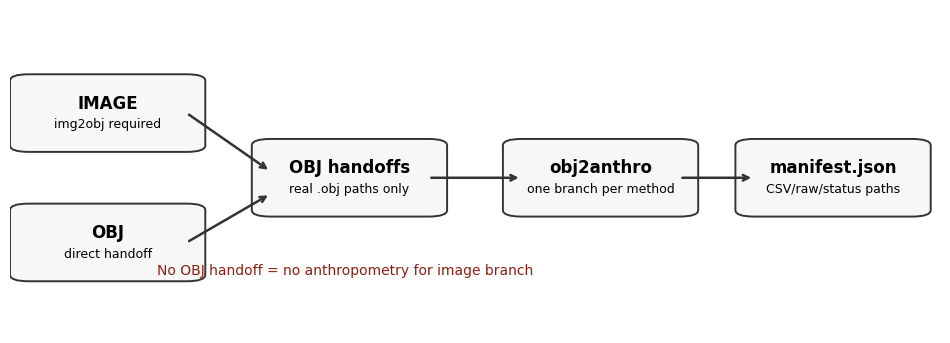

In [5]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

fig, ax = plt.subplots(figsize=(12, 4.2))
ax.axis("off")
boxes = [
    (0.02, 0.58, "IMAGE", "img2obj required"),
    (0.02, 0.18, "OBJ", "direct handoff"),
    (0.28, 0.38, "OBJ handoffs", "real .obj paths only"),
    (0.55, 0.38, "obj2anthro", "one branch per method"),
    (0.80, 0.38, "manifest.json", "CSV/raw/status paths"),
]
for x, y, title, subtitle in boxes:
    patch = FancyBboxPatch((x, y), 0.17, 0.20, boxstyle="round,pad=0.02", linewidth=1.4, facecolor="#f7f7f7", edgecolor="#333")
    ax.add_patch(patch)
    ax.text(x + 0.085, y + 0.13, title, ha="center", va="center", fontsize=12, weight="bold")
    ax.text(x + 0.085, y + 0.065, subtitle, ha="center", va="center", fontsize=9)

def arrow(start, end):
    ax.annotate("", xy=end, xytext=start, arrowprops=dict(arrowstyle="->", lw=1.8, color="#333"))

arrow((0.19, 0.68), (0.28, 0.50))
arrow((0.19, 0.28), (0.28, 0.43))
arrow((0.45, 0.48), (0.55, 0.48))
arrow((0.72, 0.48), (0.80, 0.48))
ax.text(0.36, 0.18, "No OBJ handoff = no anthropometry for image branch", ha="center", fontsize=10, color="#8a1f11")
plt.show()

## Classification Display

The visual inputs below are classified before any backend work runs. Direct OBJ input skips `img2obj`; mixed directories contain both image and direct OBJ work.

In [6]:
image_input = assets / "ssp3d_beach_volleyball_frame.png"
obj_input = demo_root / "direct_subject.obj"
mixed_dir = demo_root / "mixed_inputs"
mixed_dir.mkdir(exist_ok=True)
obj_text = "\n".join(["# visual notebook direct obj", "v 0 0 0", "v 1 0 0", "v 0 1 0", "f 1 2 3", ""])
obj_input.write_text(obj_text, encoding="utf-8")
(mixed_dir / "frame.png").write_bytes(image_input.read_bytes())
(mixed_dir / "direct_subject.obj").write_text(obj_text, encoding="utf-8")

plans = []
for label, path in [("image", image_input), ("obj", obj_input), ("mixed", mixed_dir)]:
    plan = classify_input(path)
    plans.append({
        "input kind": label,
        "images": len(plan["images"]),
        "objs": len(plan["objs"]),
        "unsupported": len(plan["unsupported"]),
        "subject groups": json.dumps(plan["subject_groups"]),
    })
display(pd.DataFrame(plans))

,input kind,images,objs,unsupported,subject groups
0,image,1,0,0,{}
1,obj,0,1,0,{}
2,mixed,1,1,0,"{""frame"": [""frame.png""]}"


## Run the Same Wrapper Path With Lightweight Visual Fixtures

The next cells monkeypatch only the heavy backend calls. `run_pipeline()` still builds the same top-level manifest, branch directories, CSV paths, and raw artifact paths used by the CLI.

In [7]:
import unified.img2obj as img2obj
import unified.obj2anthro as obj2anthro

_original_img2obj_run = img2obj.run
_original_obj2anthro_run = obj2anthro.run_pipeline

def fake_img2obj_run(input_path, method="auto", out=None):
    out_dir = Path(out)
    out_dir.mkdir(parents=True, exist_ok=True)
    native_manifest = out_dir / "manifest.json"
    handoff_obj = out_dir / "visual_subject.obj"
    handoff_obj.write_text(obj_text, encoding="utf-8")
    native_manifest.write_text(json.dumps({"inputs": [str(input_path)], "backend": method}, indent=2), encoding="utf-8")
    return {
        "status": "success",
        "native_output_dir": str(out_dir),
        "native_manifest_path": str(native_manifest),
        "obj_handoffs": [{
            "subject_id": "visual_subject",
            "method": "visual_fake_image",
            "obj_path": str(handoff_obj),
            "native_output_dir": str(out_dir),
            "native_manifest_path": str(native_manifest),
            "source_images": [str(input_path)],
            "selected_instance": "foreground_person",
        }],
        "warnings": [],
        "errors": [],
    }

def fake_obj2anthro_run(input_path, backend="auto", recursive=True, units="auto", output_dir=None, run_id=None, **kwargs):
    output_dir = Path(output_dir)
    raw_dir = output_dir / "raw"
    raw_dir.mkdir(parents=True, exist_ok=True)
    csv_path = output_dir / "results.csv"
    df = pd.DataFrame([{
        "subject_id": Path(input_path).stem,
        "backend": backend,
        "units": units,
        "status": "success",
        "height_cm": 172.4,
        "chest_cm": 94.1,
        "waist_cm": 78.8,
    }])
    df.to_csv(csv_path, index=False)
    (raw_dir / "backend_manifest.json").write_text(json.dumps({"input": str(input_path), "backend": backend}, indent=2), encoding="utf-8")
    df.attrs["output_csv"] = str(csv_path)
    df.attrs["raw_output_dir"] = str(raw_dir)
    return df

img2obj.run = fake_img2obj_run
obj2anthro.run_pipeline = fake_obj2anthro_run
print("lightweight stage backends installed")

lightweight stage backends installed


In [8]:
visual_run = run_pipeline(
    image_input,
    image_method="auto",
    anthro_method="slice",
    units="auto",
    out=demo_root / "image_run",
)
manifest_path = Path(visual_run["manifest_path"])
manifest = json.loads(manifest_path.read_text(encoding="utf-8"))
display(Markdown(f"**Manifest:** `{manifest_path.relative_to(repo).as_posix()}`"))
display(pd.DataFrame([{
    "run_id": manifest["run_id"],
    "status": manifest["status"],
    "image artifacts": len(manifest["image_artifact_roots"]),
    "OBJ handoffs": len(manifest["obj_handoffs"]),
    "anthro branches": len(manifest["stages"]["obj2anthro"]),
}]))

**Manifest:** `runs/visual_pipeline_walkthrough/image_run/manifest.json`

,run_id,status,image artifacts,OBJ handoffs,anthro branches
0,image_run,success,1,1,1


## Handoff and Branch Tables

This is the important link: the image stage hands a concrete `.obj` path to `obj2anthro`, and the anthropometry branch reports exact CSV/raw artifact paths.

In [9]:
handoff_table = pd.DataFrame(manifest["obj_handoffs"])
branch_table = pd.DataFrame(manifest["stages"]["obj2anthro"])
display(Markdown("### OBJ handoff"))
display(handoff_table[["subject_id", "source_method", "obj_path", "native_output_dir", "selected_instance"]])
display(Markdown("### Anthropometry branch"))
display(branch_table[["source_method", "subject_id", "anthro_method", "status", "rows", "output_csv", "raw_artifact_dir"]])

### OBJ handoff

,subject_id,source_method,obj_path,native_output_dir,selected_instance
0,visual_subject,visual_fake_image,C:\Users\Clint\OneDrive\Desktop\py2mat\Penning...,C:\Users\Clint\OneDrive\Desktop\py2mat\Penning...,foreground_person


### Anthropometry branch

,source_method,subject_id,anthro_method,status,rows,output_csv,raw_artifact_dir
0,visual_fake_image,visual_subject,slice,success,1,C:\Users\Clint\OneDrive\Desktop\py2mat\Penning...,C:\Users\Clint\OneDrive\Desktop\py2mat\Penning...


## CSV Preview

The output CSV is read from the path recorded in `manifest.json`; no path guessing.

In [10]:
csv_path = Path(branch_table.iloc[0]["output_csv"])
display(pd.read_csv(csv_path))

,subject_id,backend,units,status,height_cm,chest_cm,waist_cm
0,visual_subject,slice,auto,success,172.4,94.1,78.8


## Artifact Tree

The manifest path is the root index. The stage folders below are the files a user should inspect after a run.

In [11]:
def tree_lines(root, max_depth=4):
    root = Path(root)
    lines = [root.relative_to(repo).as_posix() + "/"]
    for path in sorted(root.rglob("*")):
        rel = path.relative_to(root)
        if len(rel.parts) > max_depth:
            continue
        indent = "  " * len(rel.parts)
        suffix = "/" if path.is_dir() else ""
        lines.append(f"{indent}{path.name}{suffix}")
    return "\n".join(lines)

display(Markdown("```text\n" + tree_lines(manifest_path.parent) + "\n```"))

```text
runs/visual_pipeline_walkthrough/image_run/
  img2obj/
    manifest.json
    visual_subject.obj
  manifest.json
  obj2anthro/
    visual_fake_image/
      visual_subject/
        slice/
```

## Direct OBJ Skip Display

Direct OBJ input has no `img2obj` stage; it becomes a `direct` handoff immediately.

In [12]:
direct_run = run_pipeline(
    obj_input,
    anthro_method="slice",
    units="auto",
    out=demo_root / "direct_run",
)
direct_manifest = json.loads(Path(direct_run["manifest_path"]).read_text(encoding="utf-8"))
display(pd.DataFrame([{
    "status": direct_manifest["status"],
    "has img2obj stage": "img2obj" in direct_manifest["stages"],
    "source method": direct_manifest["obj_handoffs"][0]["source_method"],
    "branch csv": direct_manifest["stages"]["obj2anthro"][0]["output_csv"],
}]))

,status,has img2obj stage,source method,branch csv
0,success,False,direct,C:\Users\Clint\OneDrive\Desktop\py2mat\Penning...


## Restore Stage Wrappers

In [13]:
img2obj.run = _original_img2obj_run
obj2anthro.run_pipeline = _original_obj2anthro_run
print("restored stage wrappers")

restored stage wrappers
